# 01 — Datos ISIC 2019: inventario, etiquetas y exclusión OOD

**Propósito del notebook:** Documentar la procedencia del conjunto de entrenamiento de ISIC 2019, verificar la disponibilidad local de imágenes y etiquetas, construir un inventario reproducible, comprobar la coherencia entre el archivo de etiquetas y las imágenes disponibles, excluir explícitamente cualquier categoría OOD/desconocida del Challenge, y generar tablas y gráficos de distribución de clases con ejemplos visuales reales.

**Procedencia de los datos:** ISIC 2019 (International Skin Imaging Collaboration, 2019 Challenge). El conjunto de entrenamiento está compuesto por 25.331 imágenes dermatoscópicas, cada una asociada a una etiqueta diagnóstica mediante un archivo CSV de metadatos ("ground truth"). Los datos oficiales se distribuyen a través del sitio del ISIC Challenge; en este notebook primero se verifica qué existe localmente antes de indicar cualquier procedimiento de descarga.

**Tarea experimental — ocho clases diagnósticas:**

| Código | Clase |
|---|---|
| `MEL` | Melanoma |
| `NV` | Nevo melanocítico |
| `BCC` | Carcinoma basocelular |
| `AK` | Queratosis actínica |
| `BKL` | Queratosis benigna |
| `DF` | Dermatofibroma |
| `VASC` | Lesión vascular |
| `SCC` | Carcinoma espinocelular |

**Categoría OOD/desconocida:** El archivo de etiquetas de ISIC 2019 puede incluir una columna adicional (`UNK` en el Challenge original) para casos fuera de distribución o no diagnosticados dentro de las ocho clases anteriores. Si esa columna existe y contiene casos positivos, este notebook los identificará y los **excluirá explícitamente** de la tarea multiclase principal. En ningún caso se reasignarán esos casos a alguna de las ocho clases diagnósticas.

**Alcance de este notebook:** Solo inventario, validación de etiquetas, exclusión OOD y visualización descriptiva. **No se realizan particiones train/validation/test ni entrenamiento aquí**; eso corresponde al notebook `02_preprocesamiento_y_particiones.ipynb`.

**Criterio de reproducibilidad:** Todas las rutas se definen de forma relativa al proyecto (sin rutas absolutas propias del equipo local), para que este notebook pueda ejecutarse sin modificaciones tanto en el entorno local (WSL2) como en el HPC Océano PUCV.

## Rutas portables del proyecto

Para que este notebook funcione sin modificaciones tanto en el PC local (WSL2) como en el HPC Océano PUCV, ninguna ruta se escribe de forma absoluta ni específica de este equipo. En su lugar, la raíz del proyecto se localiza automáticamente buscando hacia arriba desde el directorio de trabajo hasta encontrar `requirements.txt`, que identifica de forma única la raíz del repositorio.

A partir de esa raíz se derivan las rutas esperadas para:

- Los datos de ISIC 2019 (`data/isic2019/`), que **no se versionan en git** (carpeta `data/` incluida en `.gitignore`).
- Los productos reproducibles de este notebook (inventario en CSV y figuras), que se guardan bajo `reports/` y sí se versionan, siguiendo el mismo criterio que ya usa `reports/smoke_test_b4_report.json`.

Esta celda solo define las rutas y crea los directorios de salida si no existen; todavía no verifica si el dataset está presente (eso se hace en el siguiente bloque).

In [1]:
from pathlib import Path


def find_project_root(marker: str = "requirements.txt") -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        f"No se encontró '{marker}' en ningún directorio superior a {current}. "
        "Ejecuta este notebook desde dentro del repositorio del proyecto."
    )


PROJECT_ROOT = find_project_root()

# Datos ISIC 2019 (no versionados en git; ver .gitignore -> data/)
DATA_DIR = PROJECT_ROOT / "data" / "isic2019"
IMAGES_DIR = DATA_DIR / "ISIC_2019_Training_Input"
LABELS_CSV = DATA_DIR / "ISIC_2019_Training_GroundTruth.csv"
METADATA_CSV = DATA_DIR / "ISIC_2019_Training_Metadata.csv"

# Productos reproducibles de este notebook (versionados en git)
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "isic2019"
INVENTORY_DIR = REPORTS_DIR / "inventory"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
INVENTORY_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto               : {PROJECT_ROOT}")
print(f"Directorio de datos ISIC 2019   : {DATA_DIR}")
print(f"Directorio de imágenes esperado : {IMAGES_DIR}")
print(f"CSV de etiquetas esperado       : {LABELS_CSV}")
print(f"CSV de metadatos esperado       : {METADATA_CSV}")
print(f"Directorio de figuras de salida : {FIGURES_DIR}")
print(f"Directorio de inventario de salida: {INVENTORY_DIR}")

Raíz del proyecto               : /home/milat/proyecto_de_titulo
Directorio de datos ISIC 2019   : /home/milat/proyecto_de_titulo/data/isic2019
Directorio de imágenes esperado : /home/milat/proyecto_de_titulo/data/isic2019/ISIC_2019_Training_Input
CSV de etiquetas esperado       : /home/milat/proyecto_de_titulo/data/isic2019/ISIC_2019_Training_GroundTruth.csv
CSV de metadatos esperado       : /home/milat/proyecto_de_titulo/data/isic2019/ISIC_2019_Training_Metadata.csv
Directorio de figuras de salida : /home/milat/proyecto_de_titulo/reports/figures/isic2019
Directorio de inventario de salida: /home/milat/proyecto_de_titulo/reports/inventory


## Verificación de disponibilidad local del dataset

Antes de indicar cualquier procedimiento de descarga, se comprueba qué archivos de ISIC 2019 ya existen localmente según las rutas definidas en el bloque anterior: el directorio de imágenes y los dos archivos CSV (etiquetas y metadatos). Esta celda **no descarga ni modifica nada**; solo diagnostica el estado actual del directorio `data/isic2019/` en este equipo.

Si falta algo, la salida lo indicará explícitamente. Solo después de conocer con precisión qué falta se indicará la fuente oficial y el procedimiento de obtención correspondiente.

In [3]:
def revisar_ruta(nombre: str, ruta: Path, es_directorio: bool) -> bool:
    existe = ruta.is_dir() if es_directorio else ruta.is_file()
    estado = "✓ ENCONTRADO" if existe else "✗ FALTA"
    print(f"{estado:14} | {nombre:28} | {ruta}")
    return existe

print("Verificación de disponibilidad local del dataset ISIC 2019")
print("-" * 90)

estado_imagenes = revisar_ruta("Directorio de imágenes", IMAGES_DIR, es_directorio=True)
estado_labels = revisar_ruta("CSV de etiquetas (GroundTruth)", LABELS_CSV, es_directorio=False)
estado_metadata = revisar_ruta("CSV de metadatos", METADATA_CSV, es_directorio=False)

print("-" * 90)

if estado_imagenes:
    n_imagenes = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
    print(f"Imágenes .jpg encontradas en el directorio: {n_imagenes}")

DATASET_COMPLETO = estado_imagenes and estado_labels and estado_metadata

if DATASET_COMPLETO:
    print("\nEl dataset ISIC 2019 ya está disponible localmente con la estructura esperada.")
else:
    faltantes = [
        nombre
        for nombre, ok in [
            ("directorio de imágenes", estado_imagenes),
            ("CSV de etiquetas", estado_labels),
            ("CSV de metadatos", estado_metadata),
        ]
        if not ok
    ]
    print(f"\nFalta(n) los siguientes elementos: {', '.join(faltantes)}.")
    print("No se puede continuar con el inventario hasta obtener estos archivos.")

Verificación de disponibilidad local del dataset ISIC 2019
------------------------------------------------------------------------------------------
✓ ENCONTRADO   | Directorio de imágenes       | /home/milat/proyecto_de_titulo/data/isic2019/ISIC_2019_Training_Input
✓ ENCONTRADO   | CSV de etiquetas (GroundTruth) | /home/milat/proyecto_de_titulo/data/isic2019/ISIC_2019_Training_GroundTruth.csv
✓ ENCONTRADO   | CSV de metadatos             | /home/milat/proyecto_de_titulo/data/isic2019/ISIC_2019_Training_Metadata.csv
------------------------------------------------------------------------------------------
Imágenes .jpg encontradas en el directorio: 25331

El dataset ISIC 2019 ya está disponible localmente con la estructura esperada.


## Carga y verificación del archivo de etiquetas (ground truth)

Se carga `ISIC_2019_Training_GroundTruth.csv` y se inspecciona su estructura real: columnas presentes, tipo de codificación (one-hot esperado, una columna por clase), identificador de imagen, y si existe una columna adicional para casos OOD/desconocidos del Challenge (`UNK` en la especificación oficial de ISIC 2019).

Esta celda **no asume** de antemano qué columnas trae el archivo: se listan explícitamente antes de tomar cualquier decisión sobre inclusión o exclusión de columnas.

In [4]:
import pandas as pd

df_labels = pd.read_csv(LABELS_CSV)

print(f"Filas leídas: {len(df_labels)}")
print(f"Columnas encontradas ({len(df_labels.columns)}): {list(df_labels.columns)}")
print()
print("Primeras filas:")
display(df_labels.head())
print()
print("Tipos de dato por columna:")
print(df_labels.dtypes)

Filas leídas: 25331
Columnas encontradas (10): ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

Primeras filas:


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Tipos de dato por columna:
image     object
MEL      float64
NV       float64
BCC      float64
AK       float64
BKL      float64
DF       float64
VASC     float64
SCC      float64
UNK      float64
dtype: object


## Verificación de la columna OOD (`UNK`) y consistencia del one-hot

Antes de construir el inventario, se cuantifica cuántos casos están marcados como `UNK` (fuera de las ocho clases diagnósticas) y se verifica que cada fila tenga exactamente una clase activa entre las nueve columnas (las ocho diagnósticas más `UNK`). Esto confirma que la codificación es un one-hot válido y que no hay filas ambiguas (más de una clase marcada) ni filas sin ninguna clase marcada.

Los casos `UNK` se identifican aquí únicamente con fines de diagnóstico. Se excluirán explícitamente de la tarea multiclase principal en un paso posterior; en ningún caso se reasignan a alguna de las ocho clases diagnósticas.

In [5]:
CLASES = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"]
COLUMNAS_CLASE = CLASES + ["UNK"]

suma_por_fila = df_labels[COLUMNAS_CLASE].sum(axis=1)

n_ok = int((suma_por_fila == 1.0).sum())
n_ambiguas = int((suma_por_fila > 1.0).sum())
n_sin_clase = int((suma_por_fila == 0.0).sum())

print(f"Filas con exactamente una clase activa : {n_ok}")
print(f"Filas con más de una clase activa      : {n_ambiguas}")
print(f"Filas sin ninguna clase activa          : {n_sin_clase}")

n_unk = int((df_labels["UNK"] == 1.0).sum())
n_ocho_clases = int(len(df_labels) - n_unk)

print(f"\nCasos marcados como UNK (OOD/desconocido) : {n_unk}")
print(f"Casos dentro de las ocho clases diagnósticas: {n_ocho_clases}")

print("\nConteo por clase diagnóstica (incluye filas UNK=0 solamente):")
print(df_labels[CLASES].sum().astype(int))

Filas con exactamente una clase activa : 25331
Filas con más de una clase activa      : 0
Filas sin ninguna clase activa          : 0

Casos marcados como UNK (OOD/desconocido) : 0
Casos dentro de las ocho clases diagnósticas: 25331

Conteo por clase diagnóstica (incluye filas UNK=0 solamente):
MEL      4522
NV      12875
BCC      3323
AK        867
BKL      2624
DF        239
VASC      253
SCC       628
dtype: int64


## Exclusión explícita de casos OOD y asignación de clase e índice

Aunque la verificación anterior mostró 0 casos `UNK` en este archivo, la exclusión se implementa de forma explícita y no se omite del código: cualquier fila con `UNK == 1` se filtraría aquí antes de continuar, y nunca se reasigna a una de las ocho clases diagnósticas.

Sobre las filas restantes (las ocho clases), se deriva una columna `class` (a partir de la columna one-hot activa) y una columna `class_index` según el orden fijo de clases usado en `configs/pilot_m1_m4.yaml`:

```text
AK=0, BCC=1, BKL=2, DF=3, MEL=4, NV=5, SCC=6, VASC=7

In [6]:
ORDEN_CLASES = ["AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"]
CLASE_A_INDICE = {clase: idx for idx, clase in enumerate(ORDEN_CLASES)}

n_antes = len(df_labels)
df_ocho_clases = df_labels[df_labels["UNK"] == 0.0].copy()
n_excluidos_ood = n_antes - len(df_ocho_clases)

print(f"Filas totales en el CSV       : {n_antes}")
print(f"Filas excluidas por UNK == 1  : {n_excluidos_ood}")
print(f"Filas retenidas (8 clases)    : {len(df_ocho_clases)}")

df_ocho_clases["class"] = df_ocho_clases[ORDEN_CLASES].idxmax(axis=1)
df_ocho_clases["class_index"] = df_ocho_clases["class"].map(CLASE_A_INDICE)

print("\nOrden de clases -> índice:")
for clase, idx in CLASE_A_INDICE.items():
    print(f"  {clase:5} -> {idx}")

print("\nConteo por clase tras asignación (debe coincidir con el conteo anterior):")
print(df_ocho_clases["class"].value_counts().reindex(ORDEN_CLASES))

Filas totales en el CSV       : 25331
Filas excluidas por UNK == 1  : 0
Filas retenidas (8 clases)    : 25331

Orden de clases -> índice:
  AK    -> 0
  BCC   -> 1
  BKL   -> 2
  DF    -> 3
  MEL   -> 4
  NV    -> 5
  SCC   -> 6
  VASC  -> 7

Conteo por clase tras asignación (debe coincidir con el conteo anterior):
class
AK        867
BCC      3323
BKL      2624
DF        239
MEL      4522
NV      12875
SCC       628
VASC      253
Name: count, dtype: int64


## Construcción del inventario: cruce entre etiquetas e imágenes reales

Se construye la ruta de archivo esperada para cada `image_id` del CSV y se verifica, para las 25.331 filas retenidas:

- Que exista un archivo `.jpg` en disco para cada fila del CSV (etiquetas sin imagen).
- Que no existan archivos `.jpg` en el directorio que no aparezcan en el CSV (imágenes sin etiqueta, "huérfanas").
- Que no haya identificadores de imagen duplicados en el CSV.

El resultado de esta celda determina si el inventario es coherente antes de guardarlo como artefacto reproducible.

In [7]:
df_ocho_clases["image_path"] = df_ocho_clases["image"].apply(
    lambda image_id: IMAGES_DIR / f"{image_id}.jpg"
)

n_duplicados = int(df_ocho_clases["image"].duplicated().sum())
print(f"Identificadores de imagen duplicados en el CSV: {n_duplicados}")

existe_archivo = df_ocho_clases["image_path"].apply(lambda p: p.is_file())
n_faltantes = int((~existe_archivo).sum())
print(f"Filas del CSV sin archivo .jpg correspondiente: {n_faltantes}")

if n_faltantes > 0:
    print("Ejemplos de archivos faltantes:")
    print(df_ocho_clases.loc[~existe_archivo, "image"].head(10).to_list())

archivos_en_disco = {p.stem for p in IMAGES_DIR.glob("*.jpg")}
ids_en_csv = set(df_ocho_clases["image"])
huerfanos = archivos_en_disco - ids_en_csv
print(f"\nArchivos .jpg en disco sin fila correspondiente en el CSV: {len(huerfanos)}")
if huerfanos:
    print("Ejemplos de archivos huérfanos:")
    print(list(huerfanos)[:10])

inventario_coherente = (n_duplicados == 0) and (n_faltantes == 0) and (len(huerfanos) == 0)
print(f"\nInventario coherente (sin duplicados, sin faltantes, sin huérfanos): {inventario_coherente}")

Identificadores de imagen duplicados en el CSV: 0
Filas del CSV sin archivo .jpg correspondiente: 0

Archivos .jpg en disco sin fila correspondiente en el CSV: 0

Inventario coherente (sin duplicados, sin faltantes, sin huérfanos): True


## Guardado del inventario reproducible

Se guarda el inventario final (identificador de imagen, ruta de archivo, clase e índice de clase) en `reports/inventory/`, versionado en git. Este archivo será la entrada única de datos para el notebook `02_preprocesamiento_y_particiones.ipynb`, evitando repetir la verificación de disponibilidad, coherencia y exclusión OOD en cada notebook posterior.

Se guarda la ruta de imagen como texto relativo a `PROJECT_ROOT`, no como ruta absoluta, para mantener portabilidad entre el PC local y el HPC Océano.

In [8]:
df_inventario = df_ocho_clases[["image", "class", "class_index"]].copy()
df_inventario["image_path_relative"] = df_ocho_clases["image_path"].apply(
    lambda p: str(p.relative_to(PROJECT_ROOT))
)

INVENTARIO_CSV = INVENTORY_DIR / "isic2019_inventario_ocho_clases.csv"
df_inventario.to_csv(INVENTARIO_CSV, index=False)

print(f"Inventario guardado en: {INVENTARIO_CSV}")
print(f"Filas guardadas: {len(df_inventario)}")
display(df_inventario.head())

Inventario guardado en: /home/milat/proyecto_de_titulo/reports/inventory/isic2019_inventario_ocho_clases.csv
Filas guardadas: 25331


,image,class,class_index,image_path_relative
0,ISIC_0000000,NV,5,data/isic2019/ISIC_2019_Training_Input/ISIC_00...
1,ISIC_0000001,NV,5,data/isic2019/ISIC_2019_Training_Input/ISIC_00...
2,ISIC_0000002,MEL,4,data/isic2019/ISIC_2019_Training_Input/ISIC_00...
3,ISIC_0000003,NV,5,data/isic2019/ISIC_2019_Training_Input/ISIC_00...
4,ISIC_0000004,MEL,4,data/isic2019/ISIC_2019_Training_Input/ISIC_00...


## Tabla y gráfico de distribución de clases

Se genera una tabla con el conteo y porcentaje de cada una de las ocho clases sobre el total de 25.331 imágenes, y un gráfico de barras que documenta visualmente el desbalance del dataset (`NV` mayoritaria; `DF` y `VASC` minoritarias). Este gráfico se guarda en `reports/figures/isic2019/` como artefacto reproducible para el informe.

,conteo,porcentaje
class,,
AK,867,3.42
BCC,3323,13.12
BKL,2624,10.36
DF,239,0.94
MEL,4522,17.85
NV,12875,50.83
SCC,628,2.48
VASC,253,1.00


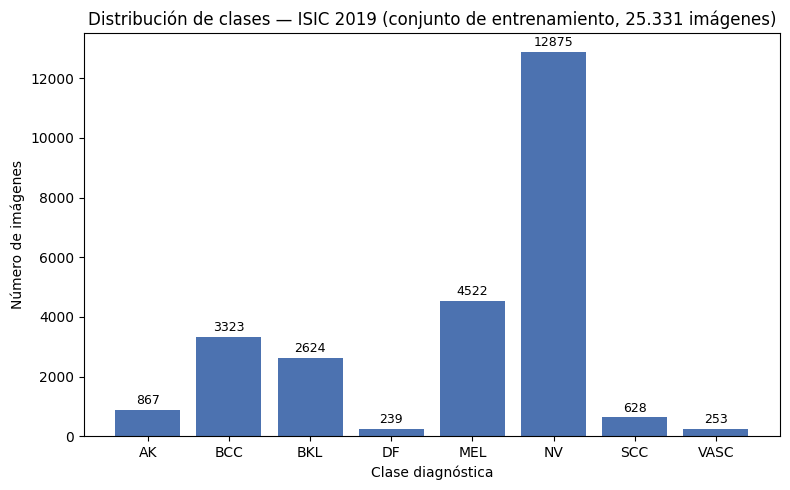


Figura guardada en: /home/milat/proyecto_de_titulo/reports/figures/isic2019/distribucion_clases_isic2019.png


In [9]:
import matplotlib.pyplot as plt

tabla_distribucion = (
    df_inventario["class"]
    .value_counts()
    .reindex(ORDEN_CLASES)
    .rename("conteo")
    .to_frame()
)
tabla_distribucion["porcentaje"] = (
    100 * tabla_distribucion["conteo"] / len(df_inventario)
).round(2)

display(tabla_distribucion)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tabla_distribucion.index, tabla_distribucion["conteo"], color="#4C72B0")
ax.set_xlabel("Clase diagnóstica")
ax.set_ylabel("Número de imágenes")
ax.set_title("Distribución de clases — ISIC 2019 (conjunto de entrenamiento, 25.331 imágenes)")
for i, valor in enumerate(tabla_distribucion["conteo"]):
    ax.text(i, valor + 200, str(valor), ha="center", fontsize=9)
fig.tight_layout()

FIGURA_DISTRIBUCION = FIGURES_DIR / "distribucion_clases_isic2019.png"
fig.savefig(FIGURA_DISTRIBUCION, dpi=150)
plt.show()

print(f"\nFigura guardada en: {FIGURA_DISTRIBUCION}")

## Ejemplos visuales reales por clase

Se muestra una imagen real de ejemplo por cada una de las ocho clases diagnósticas, seleccionada aleatoriamente con semilla fija para reproducibilidad. Esto permite una inspección cualitativa antes de avanzar al preprocesamiento y evita trabajar a ciegas con la sola información tabular.

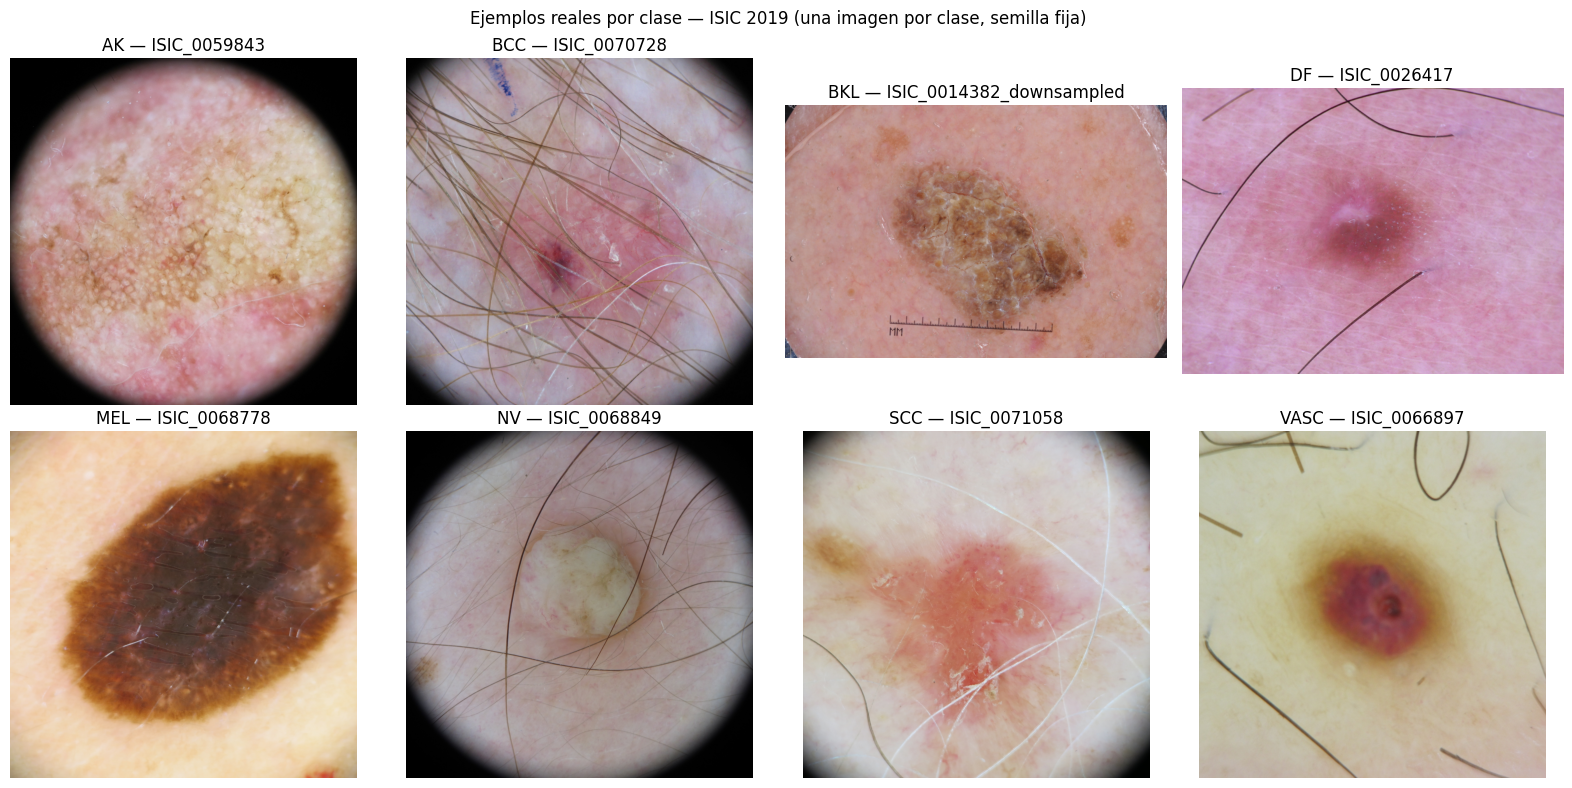


Figura guardada en: /home/milat/proyecto_de_titulo/reports/figures/isic2019/ejemplos_por_clase_isic2019.png


In [10]:
from PIL import Image

SEMILLA_EJEMPLOS = 42
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, clase in zip(axes.flat, ORDEN_CLASES):
    fila_ejemplo = (
        df_inventario[df_inventario["class"] == clase]
        .sample(n=1, random_state=SEMILLA_EJEMPLOS)
        .iloc[0]
    )
    ruta_imagen = PROJECT_ROOT / fila_ejemplo["image_path_relative"]
    imagen = Image.open(ruta_imagen)

    ax.imshow(imagen)
    ax.set_title(f"{clase} — {fila_ejemplo['image']}")
    ax.axis("off")

fig.suptitle("Ejemplos reales por clase — ISIC 2019 (una imagen por clase, semilla fija)")
fig.tight_layout()

FIGURA_EJEMPLOS = FIGURES_DIR / "ejemplos_por_clase_isic2019.png"
fig.savefig(FIGURA_EJEMPLOS, dpi=150)
plt.show()

print(f"\nFigura guardada en: {FIGURA_EJEMPLOS}")

## Resumen y estado al cierre de este notebook

**Verificado con datos reales de ISIC 2019 (no sintéticos):**

- Dataset descargado y verificado: 25.331 imágenes `.jpg` + `ISIC_2019_Training_GroundTruth.csv` + `ISIC_2019_Training_Metadata.csv`.
- Etiquetas cargadas: 10 columnas (`image` + 8 clases + `UNK`), one-hot válido en el 100% de las filas (sin ambigüedades, sin filas vacías).
- Columna OOD/desconocida (`UNK`) verificada explícitamente: 0 casos positivos en este archivo. La regla de exclusión quedó implementada en código, no solo declarada, para mantenerse válida si se usara otro archivo de etiquetas en el futuro.
- Inventario cruzado contra archivos en disco: 0 duplicados, 0 etiquetas sin imagen, 0 imágenes sin etiqueta.
- Distribución de clases confirmada empíricamente: `NV` = 50,83%, `MEL` = 17,85%, `BCC` = 13,12%, `BKL` = 10,36%, `AK` = 3,42%, `SCC` = 2,48%, `VASC` = 1,00%, `DF` = 0,94%. Coincide con el desbalance documentado en el informe y la presentación de avance.
- Ejemplos visuales reales verificados para las ocho clases.

**Artefactos guardados (versionables en `reports/`):**

- `reports/inventory/isic2019_inventario_ocho_clases.csv`
- `reports/figures/isic2019/distribucion_clases_isic2019.png`
- `reports/figures/isic2019/ejemplos_por_clase_isic2019.png`

**Explícitamente fuera de alcance de este notebook:** no se realizó ninguna partición train/validation/test, ni cálculo de pesos de clase, ni entrenamiento. Eso corresponde a `02_preprocesamiento_y_particiones.ipynb`, que debe leer `isic2019_inventario_ocho_clases.csv` como única fuente de datos en lugar de repetir la carga y verificación del CSV original.